# 📘 Module 6.1 — CLIP & Multimodal Basics

**Goal:** Understand Vision-Language Models (VLMs) that bridge images and text.

## What are VLMs?
VLMs understand **both** images and text, enabling:
- 🔍 **Zero-shot classification:** Classify objects never seen during training
- 📝 **Image captioning:** "A car is turning left at an intersection"
- ❓ **Visual question answering:** "Is the traffic light green?" → "Yes"
- 🎯 **Open-vocabulary detection:** Detect any object described in text

## CLIP (Contrastive Language-Image Pre-training)
By OpenAI (2021) — the foundational VLM that changed computer vision.

```
Image Encoder (ViT/ResNet) ──► Image Embedding  ─┐
                                                    ├─► Cosine Similarity
Text Encoder (Transformer) ──► Text Embedding   ─┘

Training: Match image-text pairs, push non-matching apart
```

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

## 1. Contrastive Learning — The Core Idea

Given a batch of N image-text pairs:
- **Positive pairs:** Image[i] matches Text[i] → similarity should be HIGH
- **Negative pairs:** Image[i] with Text[j] (i≠j) → similarity should be LOW

In [2]:
class SimpleCLIP(nn.Module):
    """
    Simplified CLIP implementation.
    Real CLIP uses ViT-L/14 + 63M text-image pairs from the internet.
    """
    
    def __init__(self, image_dim=512, text_dim=512, embed_dim=256):
        super().__init__()
        
        # Image encoder (simplified — real CLIP uses ViT)
        self.image_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 1024),
            nn.ReLU(),
            nn.Linear(1024, image_dim),
        )
        
        # Text encoder (simplified — real CLIP uses Transformer)
        self.text_encoder = nn.Sequential(
            nn.Linear(100, 512),  # 100-dim text features
            nn.ReLU(),
            nn.Linear(512, text_dim),
        )
        
        # Projection heads (map to shared embedding space)
        self.image_proj = nn.Linear(image_dim, embed_dim)
        self.text_proj = nn.Linear(text_dim, embed_dim)
        
        # Learnable temperature parameter
        self.temperature = nn.Parameter(torch.tensor(0.07))
    
    def encode_image(self, image):
        features = self.image_encoder(image)
        embedding = self.image_proj(features)
        return F.normalize(embedding, dim=-1)  # L2 normalize
    
    def encode_text(self, text):
        features = self.text_encoder(text)
        embedding = self.text_proj(features)
        return F.normalize(embedding, dim=-1)  # L2 normalize
    
    def forward(self, images, texts):
        # Get embeddings
        image_embeds = self.encode_image(images)  # (N, embed_dim)
        text_embeds = self.encode_text(texts)      # (N, embed_dim)
        
        # Compute similarity matrix
        logits = (image_embeds @ text_embeds.T) / self.temperature
        
        return logits

# Test
clip = SimpleCLIP()
images = torch.randn(8, 3, 224, 224)  # 8 images
texts = torch.randn(8, 100)            # 8 text descriptions

logits = clip(images, texts)
print(f"Similarity matrix: {logits.shape}")
print(f"\nDiagonal = matching pairs (should be high)")
print(f"Off-diagonal = non-matching (should be low)")

Similarity matrix: torch.Size([8, 8])

Diagonal = matching pairs (should be high)
Off-diagonal = non-matching (should be low)


In [3]:
# --- CLIP Loss Function ---
def clip_loss(logits):
    """Symmetric cross-entropy loss for CLIP."""
    labels = torch.arange(len(logits), device=logits.device)
    loss_i2t = F.cross_entropy(logits, labels)      # Image → Text
    loss_t2i = F.cross_entropy(logits.T, labels)    # Text → Image
    return (loss_i2t + loss_t2i) / 2

loss = clip_loss(logits)
print(f"CLIP loss: {loss.item():.4f}")
print(f"Random baseline: {np.log(8):.4f} (ln(batch_size))")

CLIP loss: 2.1682
Random baseline: 2.0794 (ln(batch_size))


## 2. Zero-Shot Classification with CLIP

The magic of CLIP: classify images using **any text description** — no fine-tuning needed!

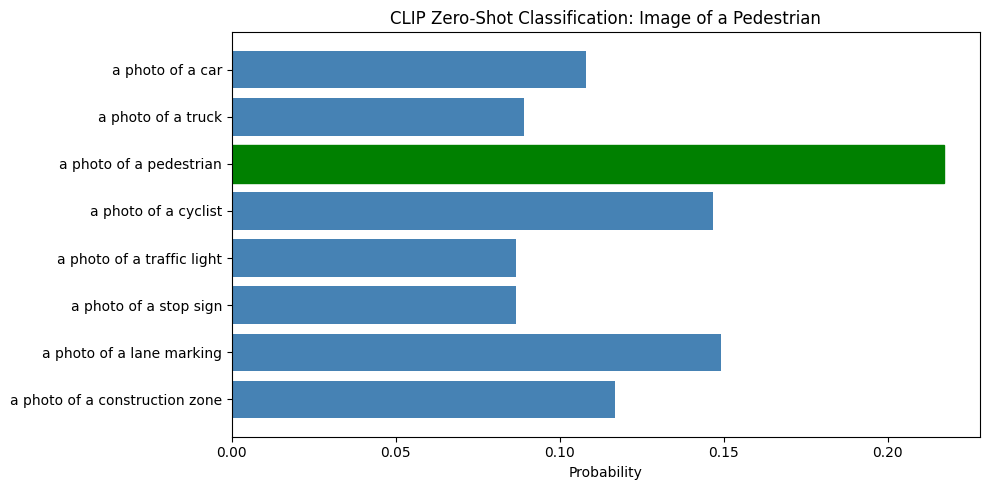

Predicted class: a photo of a pedestrian
Confidence: 21.7%

✨ No training on these specific classes — pure zero-shot!


In [4]:
# --- Zero-Shot Classification Concept ---

# ADAS classes as text prompts
adas_classes = [
    "a photo of a car",
    "a photo of a truck",
    "a photo of a pedestrian",
    "a photo of a cyclist",
    "a photo of a traffic light",
    "a photo of a stop sign",
    "a photo of a lane marking",
    "a photo of a construction zone",
]

# Simulated similarity scores (normally computed by CLIP)
np.random.seed(42)
# Image of a pedestrian would have high similarity with "pedestrian" class
similarities = np.random.randn(len(adas_classes)) * 0.3
similarities[2] = 0.85  # High similarity with "pedestrian"
similarities[0] = 0.15  # Some similarity with "car" (car in background)

probs = np.exp(similarities) / np.exp(similarities).sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(adas_classes, probs, color='steelblue')
bars[2].set_color('green')  # Highlight correct class
ax.set_xlabel('Probability')
ax.set_title('CLIP Zero-Shot Classification: Image of a Pedestrian')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Predicted class: {adas_classes[np.argmax(probs)]}")
print(f"Confidence: {probs.max():.1%}")
print(f"\n✨ No training on these specific classes — pure zero-shot!")

## 3. Modern VLMs for ADAS

| Model | Architecture | ADAS Application |
|-------|-------------|------------------|
| **CLIP** | ViT + Text Transformer | Zero-shot classification |
| **BLIP-2** | ViT + Q-Former + LLM | Image captioning, VQA |
| **LLaVA** | ViT + LLaMA | Visual conversation |
| **GPT-4V** | Proprietary | Scene understanding |
| **Florence-2** | DaViT + LLM | Detection, segmentation |
| **Grounding DINO** | DINO + Text | Open-vocabulary detection |

In [5]:
# --- Using HuggingFace CLIP (uncomment to run) ---

# from transformers import CLIPProcessor, CLIPModel
# from PIL import Image
# 
# model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
# 
# # Load an image
# image = Image.open("driving_scene.jpg")
# 
# # Define ADAS classes
# texts = ["a car on the road", "a pedestrian crossing", "a traffic light", "an empty road"]
# 
# inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
# outputs = model(**inputs)
# 
# probs = outputs.logits_per_image.softmax(dim=1)
# for text, prob in zip(texts, probs[0]):
#     print(f"{text}: {prob:.1%}")

print("💡 Uncomment above code and install transformers to use real CLIP")
print("CLIP can be used for zero-shot scene understanding in ADAS!")

💡 Uncomment above code and install transformers to use real CLIP
CLIP can be used for zero-shot scene understanding in ADAS!


---
## ✅ Key Takeaways

1. **VLMs** connect vision and language in a shared embedding space
2. **CLIP** enables zero-shot classification — no task-specific training needed
3. **Contrastive learning** aligns matching image-text pairs, separates non-matching
4. VLMs enable **open-vocabulary detection** — detect objects described in natural language
5. For ADAS: VLMs enable scene narration, anomaly detection, and flexible object recognition

---
## 📖 Next Steps
➡️ **Next notebook:** [02_vlm_for_adas.ipynb](02_vlm_for_adas.ipynb) — VLMs applied to ADAS scenarios